# Inference — AE v5

Deteksi anomali pada **test data** (Bulan 6). Threshold per `(id_user, kategori_detail)` dari model_meta.pkl.

In [15]:
import joblib
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

DATA_DIR  = '../../../data/ae_3pct'
MODEL_DIR = '../../../model/ae_3pct'

## Load Model & Metadata

In [16]:
autoencoder = tf.keras.models.load_model(
    f'{MODEL_DIR}/autoencoder.keras', compile=False
)
model_meta  = joblib.load(f'{MODEL_DIR}/model_meta.pkl')
pre_meta    = joblib.load(f'{MODEL_DIR}/preprocessing_meta.pkl')

SCALED_COLS  = model_meta['scaled_cols']
threshold_uk = model_meta['threshold_user_kat']
threshold_kat = model_meta['threshold_kat']
scaler        = pre_meta['scaler']
FEATURE_COLS  = pre_meta['feature_cols']

print("Model input shape :", autoencoder.input_shape)
print("Threshold entries :", len(threshold_uk))

Model input shape : (None, 5)
Threshold entries : 4013


## Preprocess Test Data

In [17]:
df_test = pd.read_csv(f'{DATA_DIR}/df_transaksi.csv', parse_dates=['timestamp'])
df_test = (
    df_test[
        (df_test['phase'] == 'test') &
        (df_test['tipe_mutasi'] == 'Debit') &
        df_test['kategori_detail_encoded'].notna()
    ]
    .copy()
    .reset_index(drop=True)
)
df_test['kategori_detail_encoded'] = df_test['kategori_detail_encoded'].astype(float)

_z = pre_meta['z_stats']
_tmp = df_test[['id_user', 'kategori_detail', 'nominal']].merge(
    _z, on=['id_user', 'kategori_detail'], how='left'
)
df_test['nominal_z_user_kat'] = np.where(
    _tmp['z_mean'].notna(),
    (_tmp['nominal'] - _tmp['z_mean']) / (_tmp['z_std'].fillna(0) + 1e-9),
    0.0
)

df_threshold = pd.read_csv(f'{DATA_DIR}/pre_threshold.csv', parse_dates=['timestamp'])

scaled = scaler.transform(df_test[FEATURE_COLS])
for i, col in enumerate(FEATURE_COLS):
    df_test[f'{col}_scaled'] = scaled[:, i]

X_test = df_test[SCALED_COLS].values.astype(np.float32)
y_true = df_test['label_anomali'].values.astype(int)

print(f"Test rows   : {len(df_test):,}")
print(f"Anomali GT  : {y_true.sum():,}  ({y_true.mean():.2%})")

Test rows   : 44,315
Anomali GT  : 1,329  (3.00%)


## Rekonstruksi & Skoring

In [18]:
X_rec = autoencoder.predict(X_test, verbose=0)
mae   = np.abs(X_test - X_rec).mean(axis=1)

df_test['mae'] = mae

def get_threshold(user_id, kategori):
    key = (user_id, kategori)
    if key in threshold_uk:
        return threshold_uk[key]
    if kategori in threshold_kat:
        return threshold_kat[kategori]
    return np.median(list(threshold_uk.values()))

df_test['threshold'] = df_test.apply(
    lambda r: get_threshold(r['id_user'], r['kategori_detail']), axis=1
)

# Hitung rata-rata nominal per (user, kategori) dari threshold data
user_cat_mean_nominal = (
    df_threshold.groupby(['id_user', 'kategori_detail'])['nominal']
    .mean()
    .rename('mean_nominal')
    .reset_index()
)
cat_mean_nominal = (
    df_threshold.groupby('kategori_detail')['nominal']
    .mean()
    .to_dict()
)

# Drop kolom lama jika cell di-rerun
df_test = df_test.drop(columns=['mean_nominal'], errors='ignore')
df_test = df_test.merge(user_cat_mean_nominal, on=['id_user', 'kategori_detail'], how='left')
df_test['mean_nominal'] = df_test['mean_nominal'].fillna(
    df_test['kategori_detail'].map(cat_mean_nominal)
)

# Anomali hanya kalau MAE tinggi DAN nominal lebih besar dari rata-rata
df_test['pred_anomali'] = (
    (df_test['mae'] > df_test['threshold']) &
    (df_test['nominal'] > df_test['mean_nominal'])
).astype(int)

print(f"Prediksi anomali : {df_test['pred_anomali'].sum():,}")
print(f"Ground truth     : {y_true.sum():,}")

Prediksi anomali : 6,000
Ground truth     : 1,329


## Evaluasi

              precision    recall  f1-score   support

      Normal       1.00      0.89      0.94     42986
     Anomali       0.19      0.88      0.32      1329

    accuracy                           0.89     44315
   macro avg       0.59      0.88      0.63     44315
weighted avg       0.97      0.89      0.92     44315



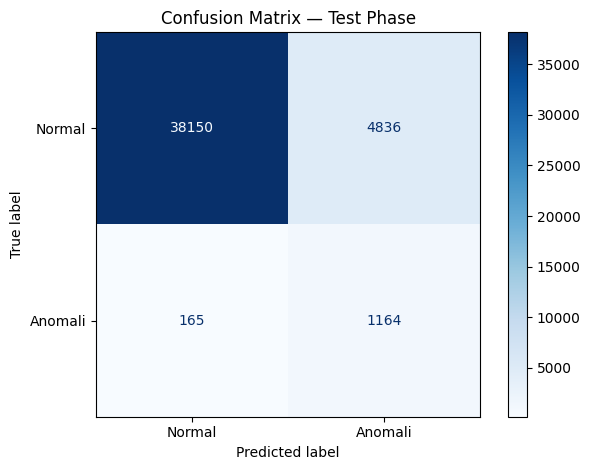

In [19]:
print(classification_report(y_true, df_test['pred_anomali'], target_names=['Normal', 'Anomali']))

cm = confusion_matrix(y_true, df_test['pred_anomali'])
disp = ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Anomali'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Test Phase')
plt.tight_layout()
plt.show()

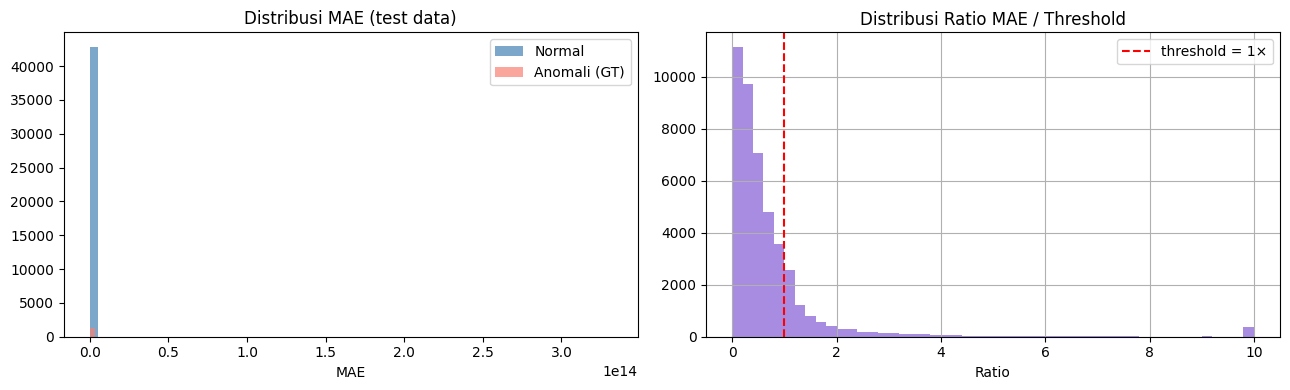

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

normal_mae  = mae[y_true == 0]
anomali_mae = mae[y_true == 1]

axes[0].hist(normal_mae,  bins=60, alpha=0.7, label='Normal',      color='steelblue')
axes[0].hist(anomali_mae, bins=60, alpha=0.7, label='Anomali (GT)', color='salmon')
axes[0].set_title('Distribusi MAE (test data)')
axes[0].set_xlabel('MAE')
axes[0].legend()

ratio = df_test['mae'] / (df_test['threshold'] + 1e-9)
df_test['ratio'] = ratio.round(3)
df_test['ratio'].clip(upper=10).hist(bins=50, ax=axes[1], color='mediumpurple', alpha=0.8)
axes[1].axvline(1.0, color='red', linestyle='--', label='threshold = 1×')
axes[1].set_title('Distribusi Ratio MAE / Threshold')
axes[1].set_xlabel('Ratio')
axes[1].legend()

plt.tight_layout()
plt.show()

In [21]:
print("=== Top Anomali Terdeteksi ===")
top_anomali = (
    df_test[df_test['pred_anomali'] == 1]
    [['id_user', 'timestamp', 'kategori_detail', 'nominal', 'mae', 'threshold', 'ratio', 'label_anomali']]
    .sort_values('ratio', ascending=False)
    .head(15)
)
display(top_anomali)

=== Top Anomali Terdeteksi ===


,id_user,timestamp,kategori_detail,nominal,mae,threshold,ratio,label_anomali
33810,USR-461,2026-06-15 15:06:00,Kesehatan & Perawatan Diri,780000.00,5.382908e+13,0.001824,2.950748e+16,1
1377,USR-135,2026-06-01 09:10:00,Investasi & Finansial,1177400.00,8.325563e+13,0.040961,2.032548e+15,1
6932,USR-200,2026-06-02 16:00:00,Kesehatan & Perawatan Diri,184951.42,2.986353e+12,0.001824,1.637029e+15,0
2174,USR-005,2026-06-01 12:00:00,Investasi & Finansial,568800.00,3.509997e+13,0.021445,1.636772e+15,1
10602,USR-255,2026-06-03 15:31:00,Kesehatan & Perawatan Diri,180367.33,2.594676e+12,0.001824,1.422323e+15,0
14712,USR-165,2026-06-04 19:50:00,Investasi & Finansial,1327500.00,9.420088e+13,0.068748,1.370236e+15,1
21077,USR-078,2026-06-06 21:59:00,Transfer P2P,478949.68,3.162223e+13,0.034378,9.198397e+14,1
18933,USR-012,2026-06-06 10:34:00,Investasi & Finansial,1932000.00,1.355980e+14,0.184108,7.365135e+14,1
14234,USR-188,2026-06-04 17:26:00,Belanja Online & Fashion,190804.33,5.103343e+13,0.146923,3.473484e+14,0
17486,USR-049,2026-06-05 19:07:00,Belanja Online & Fashion,477217.22,3.767451e+13,0.146923,2.564237e+14,0


In [22]:
per_kat = (
    df_test[df_test['label_anomali'] == 1]
    .groupby('kategori_detail')
    .apply(lambda g: pd.Series({
        'total_anomali_gt' : len(g),
        'terdeteksi'       : g['pred_anomali'].sum(),
        'recall'           : g['pred_anomali'].mean(),
    }))
    .reset_index()
    .sort_values('recall', ascending=False)
)

print("Recall per Kategori:")
display(per_kat)

Recall per Kategori:


,kategori_detail,total_anomali_gt,terdeteksi,recall
3,Hiburan & Langganan,121.0,114.0,0.942149
4,Investasi & Finansial,26.0,24.0,0.923077
0,Belanja Online & Fashion,32.0,29.0,0.906250
1,F&B dan Nongkrong,566.0,504.0,0.890459
8,Transfer P2P,70.0,62.0,0.885714
5,Kesehatan & Perawatan Diri,41.0,36.0,0.878049
2,Groceries & Kebutuhan Pokok,205.0,176.0,0.858537
9,Transportasi,247.0,208.0,0.842105
6,Produktivitas & Digital,9.0,6.0,0.666667
7,Tagihan & Utilitas,12.0,5.0,0.416667


## Anomaly Context — Narasi per Transaksi

Untuk setiap anomali terdeteksi, jabarkan **fitur penyumbang error terbesar**
menjadi kalimat yang bisa dibaca manusia (atau dikonsumsi RAG).

| Fitur | Interpretasi |
|:---|:---|
| `nominal` / `nominal_z_user_kat` | Nominal jauh dari rata-rata historis user di kategori itu |
| `hour_sin` / `hour_cos` | Jam transaksi tidak lazim untuk kategori tersebut |
| `kategori_detail_encoded` | Pola kategori menyimpang dari rekonstruksi model |

In [23]:
per_feat_err = np.abs(X_test - X_rec)

ERR_COLS = [f'err_{c}' for c in SCALED_COLS]
for j, col in enumerate(SCALED_COLS):
    df_test[f'err_{col}'] = per_feat_err[:, j]

FEAT_LABELS = [c.replace('_scaled', '') for c in SCALED_COLS]

df_err = df_test[ERR_COLS].copy()
df_err.columns = FEAT_LABELS
df_test['top_feat_1'] = df_err.idxmax(axis=1)
df_test['top_feat_2'] = df_err.apply(lambda r: r.nlargest(2).index[1], axis=1)

print('Per-feature error (mean per fitur):')
print(df_err.mean().round(4).to_string())

Per-feature error (mean per fitur):
nominal                    1.051748e+11
kategori_detail_encoded    1.095630e+10
hour_sin                   6.318683e+10
hour_cos                   3.145528e+10
nominal_z_user_kat         5.450629e+11


In [24]:
_z_lookup = {
    (r['id_user'], r['kategori_detail']): r['z_mean']
    for _, r in pre_meta['z_stats'].iterrows()
}


def _describe_hour(h):
    if h < 6:   return f'dini hari ({h:02d}:xx)'
    if h < 12:  return f'pagi ({h:02d}:xx)'
    if h < 15:  return f'siang ({h:02d}:xx)'
    if h < 19:  return f'sore ({h:02d}:xx)'
    return f'malam ({h:02d}:xx)'


def build_anomaly_context(row):
    """Narasi anomali dari top-2 fitur penyumbang error terbesar."""
    uid     = row['id_user']
    kat     = row['kategori_detail']
    nominal = row['nominal']
    hour    = pd.Timestamp(row['timestamp']).hour
    z       = row['nominal_z_user_kat']
    top2    = [row['top_feat_1'], row['top_feat_2']]
    parts   = []

    for feat in top2:
        if feat in ('nominal', 'nominal_z_user_kat'):
            baseline = _z_lookup.get((uid, kat))
            if baseline and baseline > 0:
                ratio = nominal / baseline
                parts.append(
                    f'Nominal Rp {nominal:,.0f} ({ratio:.1f}\u00d7 rata-rata historis '
                    f'user di {kat}: Rp {baseline:,.0f})'
                )
                if abs(z) >= 2.0:
                    lbl = 'sangat tinggi' if z > 0 else 'sangat rendah'
                    parts.append(
                        f'Z-score {z:+.2f} \u2014 nominal {lbl} dibanding pola historis user ini'
                    )
            else:
                parts.append(
                    f'Nominal Rp {nominal:,.0f} tidak biasa untuk kategori {kat}'
                )

        elif feat in ('hour_sin', 'hour_cos'):
            parts.append(
                f'Waktu transaksi {_describe_hour(hour)} \u2014 jam yang tidak lazim '
                f'untuk kategori {kat}'
            )

        elif feat == 'kategori_detail_encoded':
            parts.append(
                f"Pola pengeluaran di kategori '{kat}' menyimpang dari rekonstruksi model"
            )

    seen, unique = set(), []
    for p in parts:
        if p not in seen:
            seen.add(p)
            unique.append(p)

    return ' | '.join(unique)


df_anomali = df_test[df_test['pred_anomali'] == 1].copy()
df_anomali['anomaly_context'] = df_anomali.apply(build_anomaly_context, axis=1)

print(f'Total anomali terdeteksi : {len(df_anomali):,}')
print(f'Dengan konteks          : {df_anomali["anomaly_context"].ne("").sum():,}')

Total anomali terdeteksi : 6,000
Dengan konteks          : 6,000


In [25]:
sample = (
    df_anomali
    [['id_user', 'timestamp', 'kategori_detail', 'nominal',
      'mae', 'threshold', 'ratio', 'top_feat_1', 'top_feat_2',
      'label_anomali', 'anomaly_context']]
    .sort_values('ratio', ascending=False)
    .head(10)
    .reset_index(drop=True)
)

print('=== 10 Anomali Terdeteksi — Narasi Konteks ===')
print()
for i, row in sample.iterrows():
    gt_tag = '[GT Anomali]' if row['label_anomali'] == 1 else '[False Positive]'
    print(f'#{i+1:02d} {gt_tag}')
    print(f'     User     : {row["id_user"]}')
    print(f'     Waktu    : {row["timestamp"]}')
    print(f'     Kategori : {row["kategori_detail"]}')
    print(f'     Nominal  : Rp {row["nominal"]:>15,.0f}')
    print(f'     MAE/Thr  : {row["mae"]:.4f} / {row["threshold"]:.4f}  (ratio {row["ratio"]:.2f}\u00d7)')
    print(f'     Top feat : {row["top_feat_1"]}  +  {row["top_feat_2"]}')
    print(f'     Narasi   : {row["anomaly_context"]}')
    print()

=== 10 Anomali Terdeteksi — Narasi Konteks ===

#01 [GT Anomali]
     User     : USR-461
     Waktu    : 2026-06-15 15:06:00
     Kategori : Kesehatan & Perawatan Diri
     Nominal  : Rp         780,000
     MAE/Thr  : 53829080973312.0000 / 0.0018  (ratio 29507484191540860.00×)
     Top feat : nominal_z_user_kat  +  nominal
     Narasi   : Nominal Rp 780,000 (5.2× rata-rata historis user di Kesehatan & Perawatan Diri: Rp 150,000) | Z-score +630000000000000.00 — nominal sangat tinggi dibanding pola historis user ini

#02 [GT Anomali]
     User     : USR-135
     Waktu    : 2026-06-01 09:10:00
     Kategori : Investasi & Finansial
     Nominal  : Rp       1,177,400
     MAE/Thr  : 83255634165760.0000 / 0.0410  (ratio 2032547808782881.00×)
     Top feat : nominal_z_user_kat  +  nominal
     Narasi   : Nominal Rp 1,177,400 (5.8× rata-rata historis user di Investasi & Finansial: Rp 203,000) | Z-score +974400000000000.00 — nominal sangat tinggi dibanding pola historis user ini

#03 [False Po

In [26]:
df_test['anomaly_context'] = ''
df_test.loc[df_anomali.index, 'anomaly_context'] = df_anomali['anomaly_context']

print('anomaly_context tersedia di df_test, siap disimpan ke inference_results.csv')

anomaly_context tersedia di df_test, siap disimpan ke inference_results.csv


## Simpan Hasil

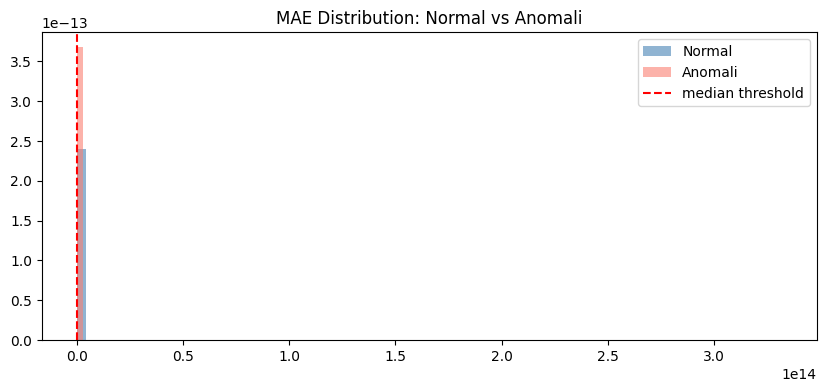

Normal MAE   — mean: 135606804480.0000, p95: 0.1009
Anomali MAE  — mean: 654462091264.0000, p95: 0.4483


In [27]:
import matplotlib.pyplot as plt

normal_mae  = df_test.loc[df_test['label_anomali'] == 0, 'mae']
anomali_mae = df_test.loc[df_test['label_anomali'] == 1, 'mae']

plt.figure(figsize=(10, 4))
plt.hist(normal_mae,  bins=80, alpha=0.6, label='Normal',  color='steelblue', density=True)
plt.hist(anomali_mae, bins=80, alpha=0.6, label='Anomali', color='salmon',    density=True)
plt.axvline(df_test['threshold'].median(), color='red', linestyle='--', label='median threshold')
plt.legend()
plt.title('MAE Distribution: Normal vs Anomali')
plt.show()

print(f"Normal MAE   — mean: {normal_mae.mean():.4f}, p95: {normal_mae.quantile(0.95):.4f}")
print(f"Anomali MAE  — mean: {anomali_mae.mean():.4f}, p95: {anomali_mae.quantile(0.95):.4f}")

In [28]:
df_test.to_csv(f'{DATA_DIR}/inference_results.csv', index=False)
print(f"inference_results.csv → {len(df_test):,} rows")

inference_results.csv → 44,315 rows
